<a href="https://colab.research.google.com/github/kerichhezron-source/Machine-Learning-Projects-/blob/main/Hezron_Logistic_Regression_To_detect_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code performs 5-fold cross-validation to evaluate the logreg_1 model's performance.

In [ ]:


from sklearn.model_selection import cross_val_score

scores = cross_val_score(logreg_1, X_train, y_train, cv = 5, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores.mean()))

Cross-validation scores:0.9746240243670284


In [ ]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test,y_pred1)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.9936


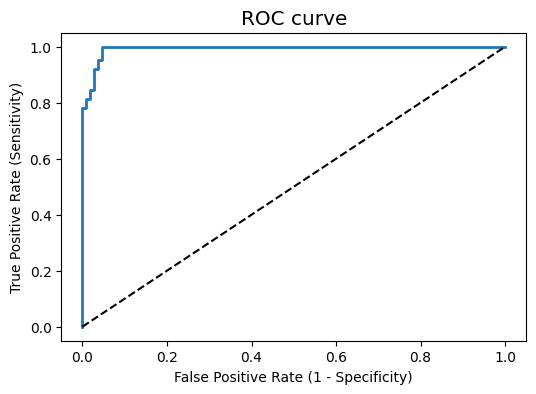

In [ ]:
# plot ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred1)

plt.figure(figsize=(6, 4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')

plt.rcParams['font.size'] = 12

plt.title('ROC curve')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()


This code imports the classification_report function from scikit-learn's metrics module and then uses it to print a detailed report of the classification performance.

In [ ]:
print(classification_report(y_test, y_pred_test_1))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       107
           1       0.93      1.00      0.96        64

    accuracy                           0.97       171
   macro avg       0.96      0.98      0.97       171
weighted avg       0.97      0.97      0.97       171



<Axes: >

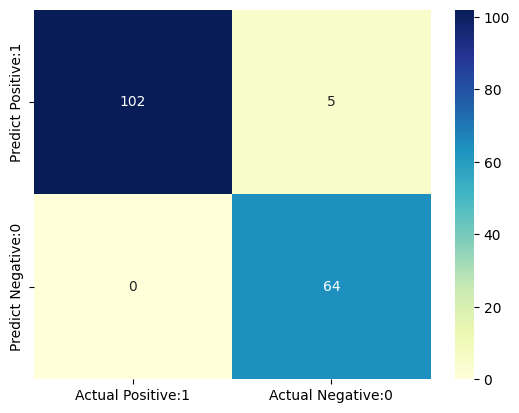

In [ ]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm_1, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [ ]:
# Print the Confusion Matrix and slice it into four categories

from sklearn.metrics import confusion_matrix

cm_1 = confusion_matrix(y_test, y_pred_test_1)

print('Confusion matrix\n\n', cm_1)

print('\nTrue Positives(TP) = ', cm_1[0,0])

print('\nTrue Negatives(TN) = ', cm_1[1,1])

print('\nFalse Positives(FP) = ', cm_1[0,1])

print('\nFalse Negatives(FN) = ', cm_1[1,0])

Confusion matrix

 [[102   5]
 [  0  64]]

True Positives(TP) =  102

True Negatives(TN) =  64

False Positives(FP) =  5

False Negatives(FN) =  0


This code calculates the accuracy score of your logreg_1 model on the test dataset

In [ ]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test_1)))

Model accuracy score: 0.9708


This code uses the logreg_1 (Logistic Regression) model, which was trained with a specified class weight threshold, to predict the class labels for the X_test dataset.

In [ ]:
y_pred_test_1 = logreg_1.predict(X_test)

y_pred_test_1

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

In [ ]:
# Set the threshold
threshold = 0.1

# Create a dictionary with class weights
class_weights = {0: threshold, 1: 1 - threshold}

# Instantiate the model with class weights
logreg_1 = LogisticRegression(class_weight=class_weights, random_state=0)

# Fit the model
logreg_1.fit(X_train, y_train)

LogisticRegression(class_weight={0: 0.1, 1: 0.9}, random_state=0)

### Fixing NameError: Consolidating dependencies for cross-validation

The `NameError` occurs because `logreg_1`, `X_train`, and `y_train` were not defined in the execution environment when cell `f54QJwbcbByk` was run. This often happens if previous cells containing their definitions were not executed.

The following cell consolidates all the necessary steps to define these variables and then performs the 5-fold cross-validation. Running this cell will ensure all dependencies are met.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- Re-establishing dependencies ---

# 1. Load data (from cell JeFPBwZm6Ux4)
df = pd.read_csv('/content/breast_cancer.csv')

# 2. Modify 'Class' column (from cell WdvumEjOPXEq)
df['Class'].replace(2, 0, inplace=True)
df['Class'].replace(4, 1, inplace=True)

# 3. Separate X and y (from cell G9w3droQQQ2D)
X = df.drop(['Class'], axis=1)
y = df['Class']

# 4. Split data (from cell VCqWoXgIQwti)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Store original column names before scaling (from cell zYq7G10NRj8K)
# This assumes X_train is still a DataFrame at this point if `cols` were defined here.
cols = X_train.columns

# 5. Scale X_train and X_test (from cell NLfu61VaR1wf)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames (from cell wv4fb0G9SRcD)
X_train = pd.DataFrame(X_train_scaled, columns=cols)
X_test = pd.DataFrame(X_test_scaled, columns=cols)

# 6. Define logreg_1 (from cell B3IyfeYrZh0Q)
# Set the threshold
threshold = 0.1
# Create a dictionary with class weights
class_weights = {0: threshold, 1: 1 - threshold}
# Instantiate the model with class weights
logreg_1 = LogisticRegression(class_weight=class_weights, random_state=0)
# Fit the model
logreg_1.fit(X_train, y_train)

# --- Now execute the original problematic code (from cell f54QJwbcbByk) ---

# Applying 5-Fold Cross Validation
scores = cross_val_score(logreg_1, X_train, y_train, cv=5, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores.mean()))


/tmp/ipykernel_2139/1114134379.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Class'].replace(2, 0, inplace=True)
/tmp/ipykernel_2139/1114134379.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

Cross-validation scores:0.9746240243670284


Experimenting with different threshold values

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

for i in range(1, 5):
    cm1 = 0
    y_pred1 = logreg.predict_proba(X_test)[:, 1]
    threshold = i / 10
    y_pred2 = (y_pred1 > threshold).astype(int)
    cm1 = confusion_matrix(y_test, y_pred2)

    print(
        'With',
        threshold,
        'threshold the Confusion Matrix is ',
        '\n\n',
        cm1,
        '\n\n',
        'with',
        cm1[0, 0] + cm1[1, 1],
        'correct predictions, ',
        '\n\n',
        cm1[0, 1],
        'Type I errors( False Positives), ',
        '\n\n',
        cm1[1, 0],
        'Type II errors( False Negatives), ',
        '\n\n',
        'Accuracy score: ',
        accuracy_score(y_test, y_pred2),
        '\n\n',
        'Sensitivity: ',
        cm1[1, 1] / (float(cm1[1, 1] + cm1[1, 0])),
        '\n\n',
        'Specificity: ',
        cm1[0, 0] / (float(cm1[0, 0] + cm1[0, 1])),
        '\n\n',
        '====================================================',
        '\n\n',
    )

With 0.1 threshold the Confusion Matrix is  

 [[102   5]
 [  0  64]] 

 with 166 correct predictions,  

 5 Type I errors( False Positives),  

 0 Type II errors( False Negatives),  

 Accuracy score:  0.9707602339181286 

 Sensitivity:  1.0 

 Specificity:  0.9532710280373832 



With 0.2 threshold the Confusion Matrix is  

 [[102   5]
 [  1  63]] 

 with 165 correct predictions,  

 5 Type I errors( False Positives),  

 1 Type II errors( False Negatives),  

 Accuracy score:  0.9649122807017544 

 Sensitivity:  0.984375 

 Specificity:  0.9532710280373832 



With 0.3 threshold the Confusion Matrix is  

 [[103   4]
 [  3  61]] 

 with 164 correct predictions,  

 4 Type I errors( False Positives),  

 3 Type II errors( False Negatives),  

 Accuracy score:  0.9590643274853801 

 Sensitivity:  0.953125 

 Specificity:  0.9626168224299065 



With 0.4 threshold the Confusion Matrix is  

 [[103   4]
 [  5  59]] 

 with 162 correct predictions,  

 4 Type I errors( False Positives),

This code calculates and prints the "Specificity" of your model.

In [ ]:
specificity = TN / (TN + FP)
print('Specificity : {0:0.4f}'.format(specificity))

Specificity : 0.9365


This code calculates and prints the "False Positive Rate" (FPR)

In [ ]:
false_positive_rate = FP / float(FP + TN)
print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

False Positive Rate : 0.0635


This code calculates and prints the "Recall" (also known as Sensitivity) of your model.

In [ ]:
recall = TP / float(TP + FN)
print('Recall or Sensitivity : {0:0.4f}'.format(recall))

Recall or Sensitivity : 0.9537


print precision score

In [ ]:
precision = TP / float(TP + FP)
print('Precision : {0:0.4f}'.format(precision))

Precision : 0.9626


print classification error

In [ ]:
classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))

Classification error : 0.0526


Print classification accuracy

In [ ]:
classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

Classification accuracy : 0.9474


In [ ]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

This code snippet imports the classification_report function from scikit-learn's metrics module and then uses it to print a detailed report of the classification performance

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       107
           1       0.94      0.92      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



Visualize confusion matrix with seaborn heatmap

<Axes: >

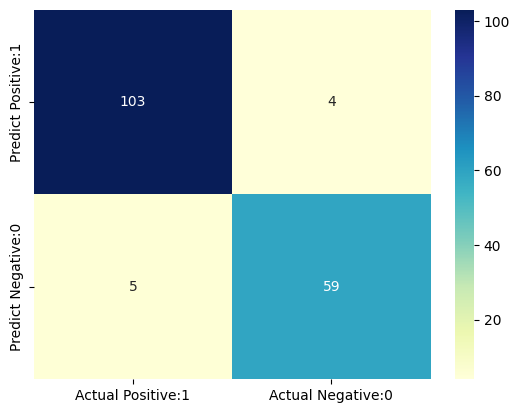

In [ ]:
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

Print the Confusion Matrix and slice it into four categories


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[103   4]
 [  5  59]]

True Positives(TP) =  103

True Negatives(TN) =  59

False Positives(FP) =  4

False Negatives(FN) =  5


returns a Series containing the counts of unique values in the y_test Series.

In [ ]:
y_test.value_counts()

,count
Class,
0,107
1,64


This code calculates and displays the accuracy of your logistic regression model on the training dataset.

In [ ]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.9805


Compare the train-set and test-set accuracy

In [ ]:
y_pred_train = logreg.predict(X_train)
y_pred_train

array([1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,

 Calculates and displays the accuracy of your logistic regression model.

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score: 0.9474


Returns the predicted probabilities that each instance in your X_test dataset belongs to the positive class (class 1).

In [ ]:
logreg.predict_proba(X_test)[:,1]

NameError: name 'logreg' is not defined

probability of getting output as 0

In [ ]:
logreg.predict_proba(X_test)[:,0]

array([9.91028143e-01, 9.94822534e-01, 6.89115770e-02, 1.32920519e-02,
       9.98150986e-01, 9.94883714e-01, 9.82715501e-01, 3.52305400e-04,
       9.95281216e-01, 9.97495911e-01, 9.55746597e-04, 9.87509569e-01,
       4.85386274e-05, 9.94822534e-01, 9.73475158e-01, 7.18054312e-01,
       6.72278367e-03, 9.48325532e-04, 3.45742180e-04, 9.82568591e-01,
       9.94822534e-01, 9.90960109e-01, 3.22362090e-01, 9.96174287e-01,
       4.51915370e-03, 4.23800042e-03, 9.89451035e-01, 9.94482693e-01,
       9.92101111e-01, 3.44590378e-03, 9.98150986e-01, 1.55445482e-04,
       1.82401537e-05, 9.92996519e-01, 9.94500810e-01, 9.92996519e-01,
       5.89542534e-03, 2.80171898e-02, 9.94500810e-01, 1.94636463e-03,
       9.84647706e-01, 9.70371295e-01, 9.95246244e-01, 9.97008752e-01,
       9.98150986e-01, 9.92743938e-01, 9.97258823e-01, 4.87026871e-04,
       9.88338524e-01, 9.92101111e-01, 6.73869746e-03, 9.89003081e-01,
       2.59358856e-02, 9.89842982e-01, 9.82568591e-01, 9.80709253e-01,
      

Uses logreg model to make predictions on the X_test dataset

In [ ]:
y_pred_test = logreg.predict(X_test)
y_pred_test

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0])

Fit the model

In [ ]:
logreg.fit(X_train, y_train)

LogisticRegression(random_state=0)

Instantiate the model

In [ ]:
logreg = LogisticRegression(random_state=0)

Train a logistic regression model on the training set


In [ ]:
from sklearn.linear_model import LogisticRegression

Summary of the Data

In [ ]:
X_train.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,5.120000e+02,5.120000e+02,5.120000e+02,5.120000e+02,512.000000,5.120000e+02,5.120000e+02,5.120000e+02,5.120000e+02
mean,-1.040834e-17,3.382711e-17,-5.377643e-17,1.908196e-17,0.000000,-4.076600e-17,-6.938894e-18,-6.938894e-18,-2.081668e-17
std,1.000978e+00,1.000978e+00,1.000978e+00,1.000978e+00,1.000978,1.000978e+00,1.000978e+00,1.000978e+00,1.000978e+00
min,-1.221435e+00,-6.986899e-01,-7.396154e-01,-6.364285e-01,-0.990024,-6.808444e-01,-9.877481e-01,-6.206996e-01,-3.374390e-01
25%,-8.646895e-01,-6.986899e-01,-7.396154e-01,-6.364285e-01,-0.546549,-6.808444e-01,-5.860587e-01,-6.206996e-01,-3.374390e-01
50%,-1.511987e-01,-6.986899e-01,-7.396154e-01,-6.364285e-01,-0.546549,-6.808444e-01,-1.843692e-01,-6.206996e-01,-3.374390e-01
75%,5.622921e-01,6.128747e-01,6.152435e-01,4.203868e-01,0.340402,4.257979e-01,6.190098e-01,3.432990e-01,-3.374390e-01
max,1.989274e+00,2.252330e+00,2.308817e+00,2.534018e+00,3.001253,1.809101e+00,2.627457e+00,2.271296e+00,4.915666e+00


The two lines convert your X_train and X_test numpy arrays back into Pandas DataFrame

In [ ]:
X_train = pd.DataFrame(X_train, columns=cols)
X_test = pd.DataFrame(X_test, columns=cols)

Uses StandardScaler from scikit-learn to standardize  features (columns) in both the training and testing datasets.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_train.columns assigns all the column names from your X_train DataFrame to a new variable called cols

In [ ]:
cols=X_train.columns

In [ ]:
X_test.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
113,1,1,1,1,2,5,1,1,1
378,3,1,1,1,2,1,2,1,1
303,5,5,5,2,5,10,4,3,1
504,4,7,8,3,4,10,9,1,1
301,1,1,1,1,2,1,1,1,1


In [ ]:
X_train.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
556,7,6,10,5,3,10,9,10,2
66,8,3,8,3,4,9,8,9,8
571,8,10,10,10,6,10,10,10,1
299,1,1,1,1,2,1,1,1,1
355,1,1,3,1,1,1,2,1,1


check the dimension of X_train and X_test

In [ ]:
X_train.shape, X_test.shape

((512, 9), (171, 9))

 Split X and y into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

 Separate the input features from the target variable

In [ ]:
X = df.drop(['Class'], axis=1)
y = df['Class']

In [ ]:
df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


modifies the 'Class' column of the DataFrame

In [ ]:
df['Class'].replace(2,0,inplace=True)
df['Class'].replace(4,1,inplace=True)

/tmp/ipykernel_2139/3097048679.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Class'].replace(2,0,inplace=True)
/tmp/ipykernel_2139/3097048679.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

returns a series containing counts of unique values in the 'Class'

In [ ]:
df['Class'].value_counts()

,count
Class,
2,444
4,239


Class visualization

Text(0, 0.5, 'Class')

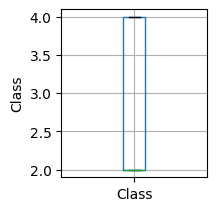

In [ ]:
plt.subplot(2, 3, 6)
fig = df.boxplot(column='Class')
fig.set_title('')
fig.set_ylabel('Class')

Mitoses Visualization

Text(0, 0.5, 'Mitoses')

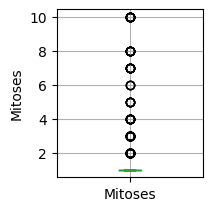

In [ ]:
plt.subplot(2, 3, 5)
fig = df.boxplot(column='Mitoses')
fig.set_title('')
fig.set_ylabel('Mitoses')

Normal Nucleoli visualization

Text(0, 0.5, 'Normal Nucleoli')

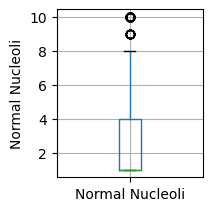

In [ ]:
plt.subplot(2, 3, 4)
fig = df.boxplot(column='Normal Nucleoli')
fig.set_title('')
fig.set_ylabel('Normal Nucleoli')

Bland Chromatin visualization

Text(0, 0.5, 'Bland Chromatin')

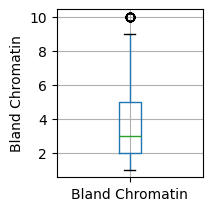

In [ ]:
plt.subplot(2, 3, 3)
fig = df.boxplot(column='Bland Chromatin')
fig.set_title('')
fig.set_ylabel('Bland Chromatin')

Bare Nuclei visualization

Text(0, 0.5, 'Bare Nuclei')

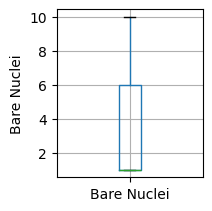

In [ ]:
plt.subplot(2, 3, 2)
fig = df.boxplot(column='Bare Nuclei')
fig.set_title('')
fig.set_ylabel('Bare Nuclei')

Single Epithelial Cell Size visualization

Text(0, 0.5, 'Single Epithelial Cell Size')

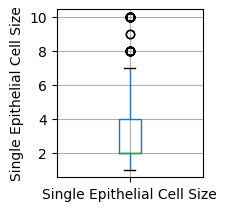

In [ ]:
plt.subplot(2,3,1)
fig=df.boxplot(column='Single Epithelial Cell Size')
fig.set_title('')
fig.set_ylabel('Single Epithelial Cell Size')

draw boxplots to visualize outliers

In [ ]:
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Marginal Adhesion visualization

Text(0, 0.5, 'Marginal Adhesion')

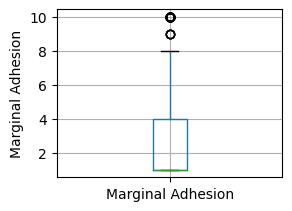

In [ ]:
plt.subplot(2,2,4)
fig = df.boxplot(column='Marginal Adhesion')
fig.set_title('')
fig.set_ylabel('Marginal Adhesion')


Uniformity of Cell Shape visualizaton

Text(0, 0.5, 'Uniformity of Cell Shape')

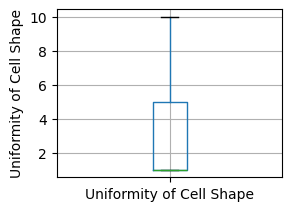

In [ ]:
plt.subplot(2,2,3)
fig = df.boxplot(column='Uniformity of Cell Shape')
fig.set_title('')
fig.set_ylabel('Uniformity of Cell Shape')


Uniformity of Cell Size visualization

Text(0, 0.5, 'Uniformity of Cell Size')

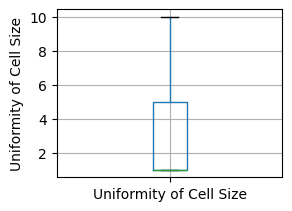

In [ ]:
plt.subplot(2,2,2)
fig = df.boxplot(column='Uniformity of Cell Size')
fig.set_title('')
fig.set_ylabel('Uniformity of Cell Size')


Clump Thickness visualization

Text(0, 0.5, 'Clump Thickness')

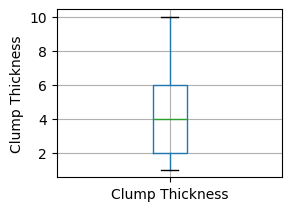

In [ ]:
plt.subplot(2,2,1)
fig = df.boxplot(column='Clump Thickness')
fig.set_title('')
fig.set_ylabel('Clump Thickness')

visualizing the outliers

In [ ]:
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

print(round(df.describe(),2)) first generate the descriptive statistic for the DataFrame numerical column then rounds all the numeric values to two decimal places

In [ ]:
print(round(df.describe(),2))

       Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
count           683.00                   683.00                    683.00   
mean              4.44                     3.15                      3.22   
std               2.82                     3.07                      2.99   
min               1.00                     1.00                      1.00   
25%               2.00                     1.00                      1.00   
50%               4.00                     1.00                      1.00   
75%               6.00                     5.00                      5.00   
max              10.00                    10.00                     10.00   

       Marginal Adhesion  Single Epithelial Cell Size  Bare Nuclei  \
count             683.00                       683.00       683.00   
mean                2.83                         3.23         3.54   
std                 2.86                         2.22         3.64   
min                 1.00  

df.isna() returns DataFrame of boolean values indicating wether each element is null,true means there is a missing value and false no missing value
.sum() when implied it counts the value of true for each column so the output seen is 0 indicating no missing values

In [ ]:
df.isna().sum()

,0
Clump Thickness,0
Uniformity of Cell Size,0
Uniformity of Cell Shape,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bare Nuclei,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0
Class,0


df.decsribe() generates descriptive statistic summary for numerical columns in the database

In [ ]:
df.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


df.info() is a Pandas DataFrame method that prints a summary of the DataFrame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clump Thickness              683 non-null    int64
 1   Uniformity of Cell Size      683 non-null    int64
 2   Uniformity of Cell Shape     683 non-null    int64
 3   Marginal Adhesion            683 non-null    int64
 4   Single Epithelial Cell Size  683 non-null    int64
 5   Bare Nuclei                  683 non-null    int64
 6   Bland Chromatin              683 non-null    int64
 7   Normal Nucleoli              683 non-null    int64
 8   Mitoses                      683 non-null    int64
 9   Class                        683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


df.columns is a Pandas DataFrame attribute that returns an Index object containing the labels of each column in the DataFrame.

In [ ]:
df.columns

Index(['Clump Thickness', 'Uniformity of Cell Size',
       'Uniformity of Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
       'Normal Nucleoli', 'Mitoses', 'Class'],
      dtype='object')

df.tail() is a Pandas DataFrame method that, by default, displays the last 5 rows of your DataFrame.

In [ ]:
df.tail()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
678,3,1,1,1,3,2,1,1,1,2
679,2,1,1,1,2,1,1,1,1,2
680,5,10,10,3,7,3,8,10,2,4
681,4,8,6,4,3,4,10,6,1,4
682,4,8,8,5,4,5,10,4,1,4


df.head() is a Pandas DataFrame method that, by default, displays the first 5 rows of your DataFrame.

In [ ]:
df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


df.shape is a Pandas DataFrame attribute that returns the dimensions of the DataFrame as a tuple

In [ ]:
df.shape

(683, 10)

df = pd.read_csv() is used to loads CSV-formatted data into a Pandas DataFrame named df.

In [ ]:
df = pd.read_csv('/content/breast_cancer(logistic_regression).csv')

seaborn is used for statistical data visualization

In [ ]:
import seaborn as sns

matplotlib.pyplot is used for data visualization

In [ ]:
import matplotlib.pyplot as lt

importing pandas as pd for data processing

In [ ]:
import pandas as pd

import numpy as np for linear agebra

In [ ]:
import numpy as np